## Data Visualization

This section previews the first 10 images in our Brain MRI Dataset to ensure everything loaded correctly. We use PyTorch's `ImageFolder` and resize the images to 512x512 pixels since some images vary in size.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


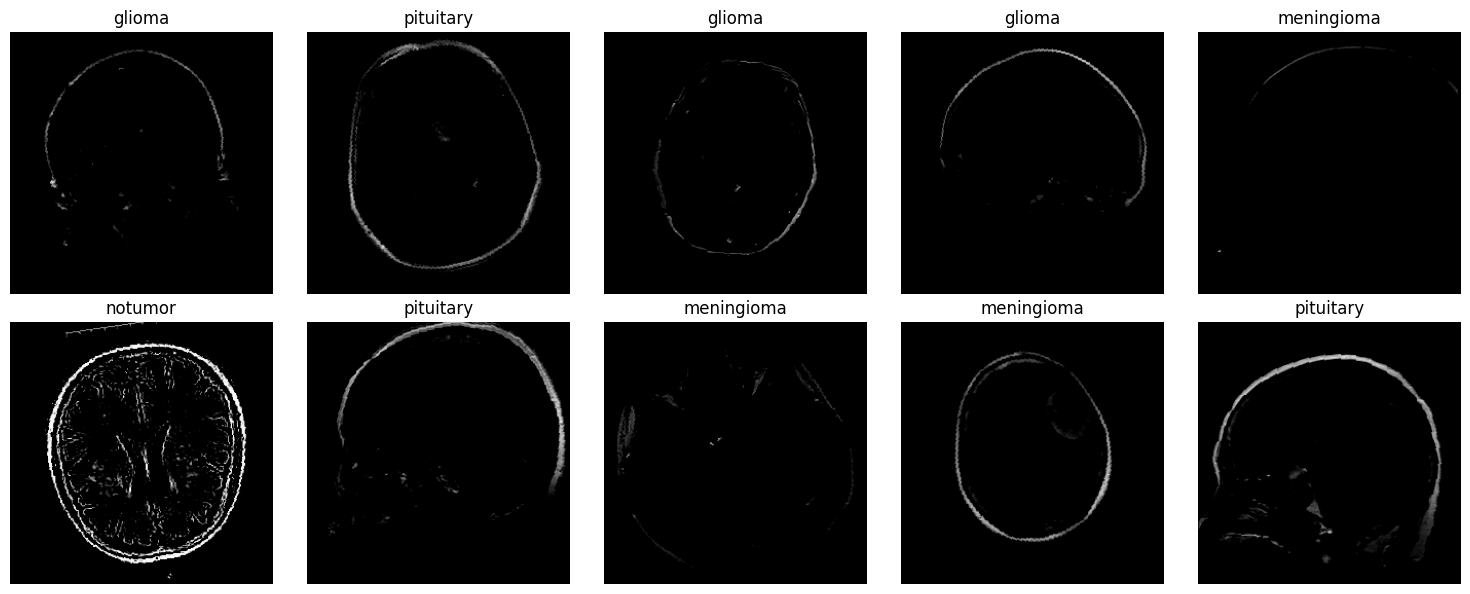

In [32]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')


# transform to make all images 256*256 and preprocessing
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),

    # add data augmentation for training
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),

    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),

])

transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),

])


# load train and test dataset paths
#train_path = '../brain_mri_dataset/Training/'
#test_path = '../brain_mri_dataset/Testing/'

# I put it in content/dataset rather than google drive to fasten the training process
!cp -r "/content/drive/MyDrive/brain_mri_dataset/" "/content/dataset"
train_path = '/content/dataset/Training/'
test_path = '/content/dataset/Testing/'

# load train/test datasets and subfolder names
train_dataset = datasets.ImageFolder(root=train_path, transform=transform_train)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform_test)

# image data loading in batches
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)


# pulls batch of 10 images to display
images, labels = next(iter(train_loader))

# class names corresponding to the folder names
class_names = train_dataset.classes

# plot the first 10 images
fig, axes = plt.subplots(2, 5, figsize=(15,6))
axes = axes.flatten()

for i in range(10):
    # PyTorch images (Channels, Height, Width) --> Matplotlib images (Height, Width, Channels)
    img = images[i].permute(1, 2, 0).numpy()

    axes[i].imshow(img) # should fix in the future to denormalize during imshow to silence warnings
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Model Definition

Define the CNN architecture, then set up the training/evaluation loop: a training function, an evaluation function, and the epoch loop that ties them together.

In [34]:
import torch.nn as nn
import torch.optim as optim

In [35]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # 256 -> 128
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # 128 -> 64
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(4, 4) # 64 -> 16
        )


        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, num_classes),
        )


    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.classifier(x)
        return x

In [36]:
# hyperparameters
num_epochs = 30
learning_rate = 1e-3 # could use scheduler to reduce learning rate in the future

model = SimpleCNN(num_classes=len(class_names))
model = model.cuda() # I'm running on Google Colab GPU; pls change to your device when running on local machine

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-4)

In [37]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Runs one training epoch, and returns (avg_loss, accuracy)."""
    model.train()

    running_loss = 0.0
    num_correct = 0
    num_samples = 0

    for t, (x, y) in enumerate(loader):
        x = x.cuda()
        y = y.cuda()

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        predicted = torch.max(output, 1)[1]
        num_correct += (predicted == y).sum().item()
        num_samples += y.size(0)
        if t % 10 == 0:
            batch_acc = (predicted == y).sum().item() / y.size(0)
            print('Iteration %d, Train: batch_loss=%.2f, acc=%.4f' % (t, loss.item(), batch_acc))

    avg_loss = running_loss / num_samples
    accuracy = num_correct / num_samples
    return avg_loss, accuracy

In [38]:
def test(model, loader, criterion):
    """Runs evaluation, and returns (avg_loss, accuracy)."""
    model.eval()

    running_loss = 0.0
    num_correct = 0
    num_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.cuda()
            y = y.cuda()

            output = model(x)
            loss = criterion(output, y)

            running_loss += loss.item() * x.size(0)
            predicted = torch.max(output, 1)[1]
            num_correct += (predicted == y).sum().item()
            num_samples += y.size(0)

    avg_loss = running_loss / num_samples
    accuracy = num_correct / num_samples
    return avg_loss, accuracy

In [ ]:
# Add tracking list in this section if needed

for e in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)

    test_loss, test_acc = test(model, test_loader, criterion)

    print('Epoch %d, Train: avg_loss=%.2f, acc=%.4f' % (e, train_loss, train_acc))
    print('Epoch %d, Eval: avg_loss=%.2f, acc=%.4f' % (e, test_loss, test_acc))


# Note: This training takes 9min for L4 GPU, 30 epochs.
# Best model @Epoch 27:
# Epoch 27, Train: avg_loss=0.22, acc=0.9207
# Epoch 27, Eval: avg_loss=0.59, acc=0.8769

Iteration 0, Train: batch_loss=1.39, acc=0.2031
Iteration 10, Train: batch_loss=1.21, acc=0.3906
Iteration 20, Train: batch_loss=1.27, acc=0.3906
Iteration 30, Train: batch_loss=1.33, acc=0.4219
Iteration 40, Train: batch_loss=0.93, acc=0.5000
Iteration 50, Train: batch_loss=0.88, acc=0.5781
Iteration 60, Train: batch_loss=0.93, acc=0.6406
Iteration 70, Train: batch_loss=0.90, acc=0.6875
Iteration 80, Train: batch_loss=0.83, acc=0.6406
Epoch 0, Train: avg_loss=1.39, acc=0.5095
Epoch 0, Eval: avg_loss=1.06, acc=0.6075
Iteration 0, Train: batch_loss=0.91, acc=0.5625
Iteration 10, Train: batch_loss=0.89, acc=0.6406
Iteration 20, Train: batch_loss=0.77, acc=0.6406
Iteration 30, Train: batch_loss=0.84, acc=0.6094
Iteration 40, Train: batch_loss=0.87, acc=0.6562
Iteration 50, Train: batch_loss=1.04, acc=0.6562
Iteration 60, Train: batch_loss=0.64, acc=0.7188
Iteration 70, Train: batch_loss=0.97, acc=0.6250
Iteration 80, Train: batch_loss=0.65, acc=0.7656
Epoch 1, Train: avg_loss=0.80, acc=0.

In [ ]:
# plot curves here if needed

In [31]:
torch.save(model.state_dict(), 'yi_simple_cnn_result.pth')
# model.load_state_dict(torch.load('yi_simple_cnn_result.pth'))